In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

In [3]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB


In [5]:
df.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [6]:
df = df.drop(columns=['Person ID', 'Sleep Disorder'])

In [7]:
df.columns

Index(['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep',
       'Physical Activity Level', 'Stress Level', 'BMI Category',
       'Blood Pressure', 'Heart Rate', 'Daily Steps'],
      dtype='str')

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Occupation'] = le.fit_transform(df['Occupation'])
df['BMI Category'] = le.fit_transform(df['BMI Category'])
df['Blood Pressure'] = le.fit_transform(df['Blood Pressure'])

In [9]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps
0,1,27,9,6.1,6,42,6,3,11,77,4200
1,1,28,1,6.2,6,60,8,0,9,75,10000
2,1,28,1,6.2,6,60,8,0,9,75,10000
3,1,28,6,5.9,4,30,8,2,22,85,3000
4,1,28,6,5.9,4,30,8,2,22,85,3000


In [10]:
X = df.drop('Quality of Sleep', axis=1)
y = df['Quality of Sleep']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [12]:
print("Data Latih :", X_train.shape)
print("Data Uji   :", X_test.shape)

Data Latih : (299, 10)
Data Uji   : (75, 10)


In [13]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [14]:
y_pred = dt.predict(X_test)

In [15]:
from sklearn.metrics import accuracy_score

akurasi_awal = accuracy_score(y_test, y_pred)
print("Akurasi Sebelum Optimasi:", akurasi_awal)

Akurasi Sebelum Optimasi: 0.9866666666666667


In [16]:
from sklearn.model_selection import GridSearchCV

parameter = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=parameter,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",Tru

In [17]:
print(grid.best_params_)

{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}


In [18]:
best_model = grid.best_estimator_

y_pred_grid = best_model.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score

akurasi_grid = accuracy_score(y_test, y_pred_grid)

print("Akurasi Setelah Optimasi:", akurasi_grid)

Akurasi Setelah Optimasi: 0.96


In [20]:
print("Akurasi Sebelum Optimasi :", akurasi_awal)
print("Akurasi Setelah Optimasi :", akurasi_grid)

Akurasi Sebelum Optimasi : 0.9866666666666667
Akurasi Setelah Optimasi : 0.96


In [21]:
print("Akurasi Setelah Optimasi:", akurasi_grid)

Akurasi Setelah Optimasi: 0.96


In [22]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_grid))

print("\nClassification Report")
print(classification_report(y_test, y_pred_grid))

Confusion Matrix
[[ 2  0  0  0  0  0]
 [ 0  1  0  0  0  0]
 [ 0  0 25  1  0  0]
 [ 0  0  0 14  2  0]
 [ 0  0  0  0 18  0]
 [ 0  0  0  0  0 12]]

Classification Report
              precision    recall  f1-score   support

           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         1
           6       1.00      0.96      0.98        26
           7       0.93      0.88      0.90        16
           8       0.90      1.00      0.95        18
           9       1.00      1.00      1.00        12

    accuracy                           0.96        75
   macro avg       0.97      0.97      0.97        75
weighted avg       0.96      0.96      0.96        75



In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_grid))

              precision    recall  f1-score   support

           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         1
           6       1.00      0.96      0.98        26
           7       0.93      0.88      0.90        16
           8       0.90      1.00      0.95        18
           9       1.00      1.00      1.00        12

    accuracy                           0.96        75
   macro avg       0.97      0.97      0.97        75
weighted avg       0.96      0.96      0.96        75



In [24]:
importance = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

                     Fitur  Importance
3           Sleep Duration    0.729733
5             Stress Level    0.135902
1                      Age    0.065027
8               Heart Rate    0.029441
9              Daily Steps    0.022598
7           Blood Pressure    0.017298
0                   Gender    0.000000
2               Occupation    0.000000
4  Physical Activity Level    0.000000
6             BMI Category    0.000000


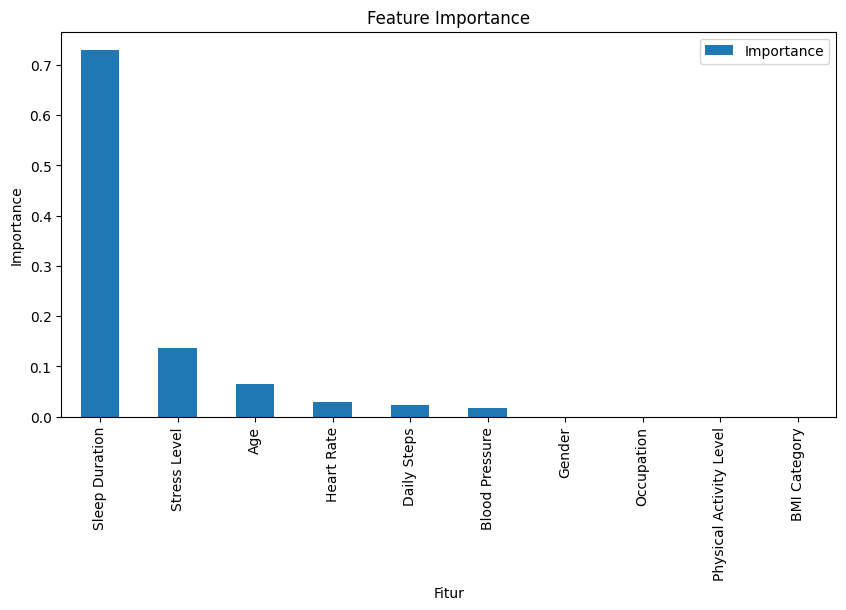

In [25]:
import matplotlib.pyplot as plt

importance.plot(
    x='Fitur',
    y='Importance',
    kind='bar',
    figsize=(10,5)
)

plt.title("Feature Importance")
plt.xlabel("Fitur")
plt.ylabel("Importance")
plt.show()

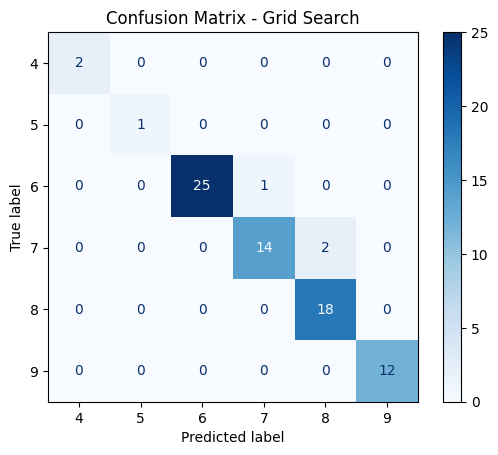

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(grid, X_test, y_test, cmap="Blues")
plt.title("Confusion Matrix - Grid Search")
plt.show()

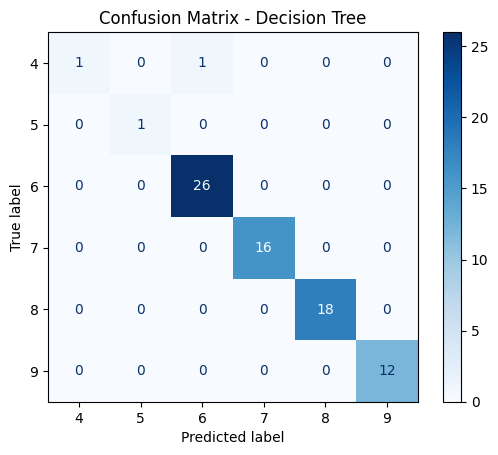

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test, cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

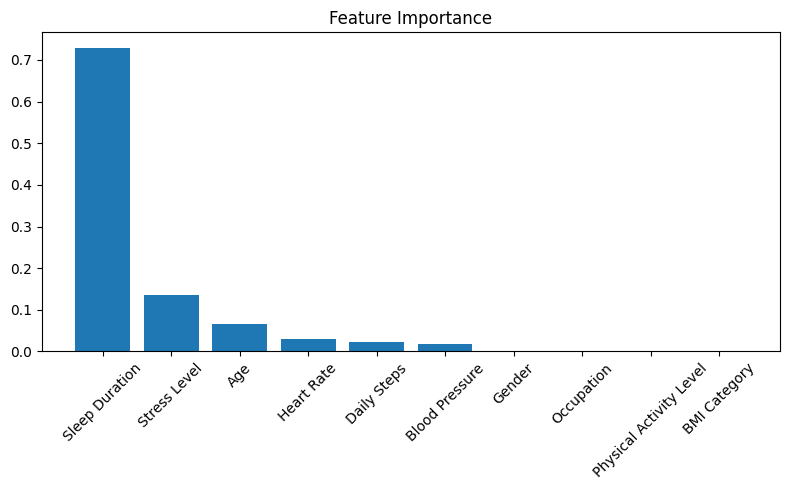

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': grid.best_estimator_.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,5))
plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.tight_layout()

plt.show()

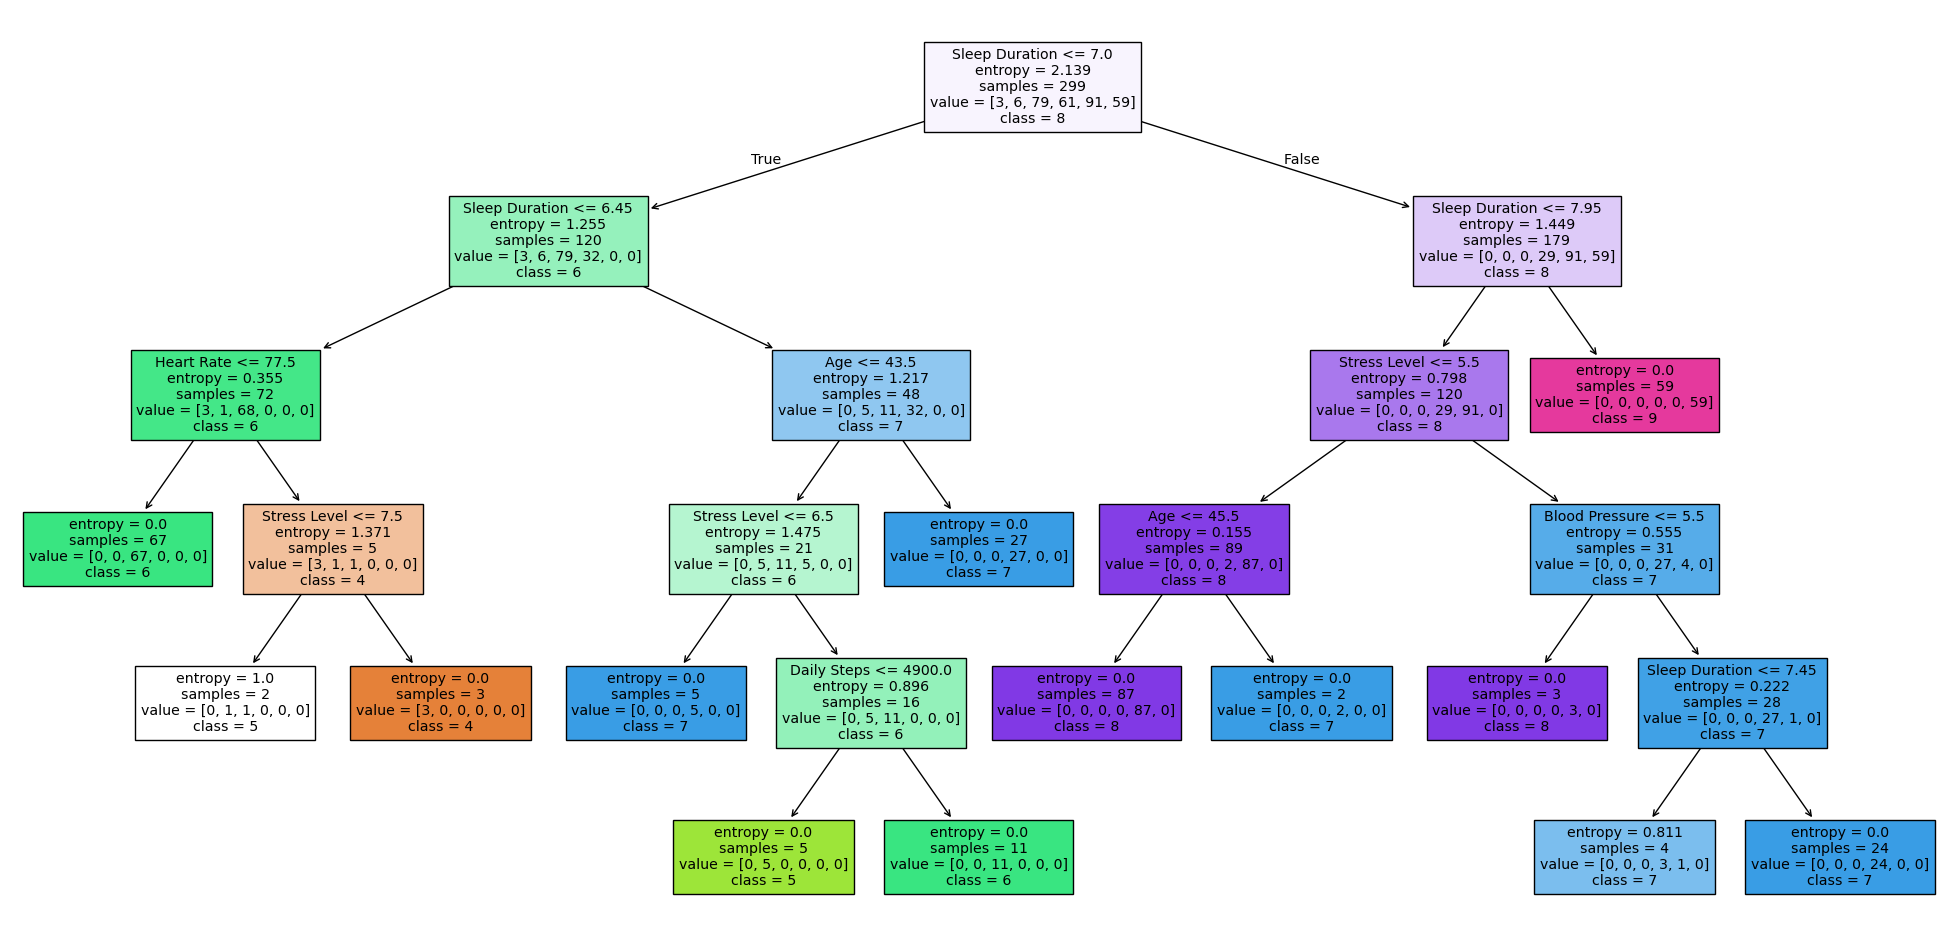

In [31]:
plt.figure(figsize=(25,12))

plot_tree(
    grid.best_estimator_,
    feature_names=X.columns,
    class_names=[str(i) for i in sorted(y.unique())],
    filled=True
)

plt.show()

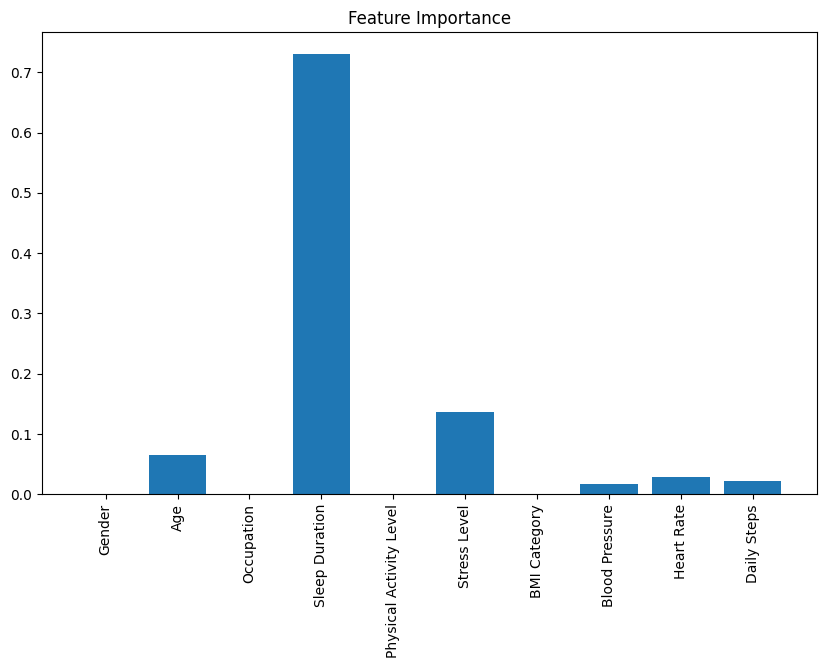

In [32]:
importances = grid.best_estimator_.feature_importances_

plt.figure(figsize=(10,6))
plt.bar(X.columns, importances)
plt.xticks(rotation=90)
plt.title("Feature Importance")
plt.show()

In [33]:
from sklearn.metrics import accuracy_score

print("Akurasi Training (Sebelum Optimasi):", accuracy_score(y_train, dt.predict(X_train)))
print("Akurasi Training (Setelah Optimasi):", accuracy_score(y_train, best_model.predict(X_train)))

Akurasi Training (Sebelum Optimasi): 1.0
Akurasi Training (Setelah Optimasi): 0.9933110367892977


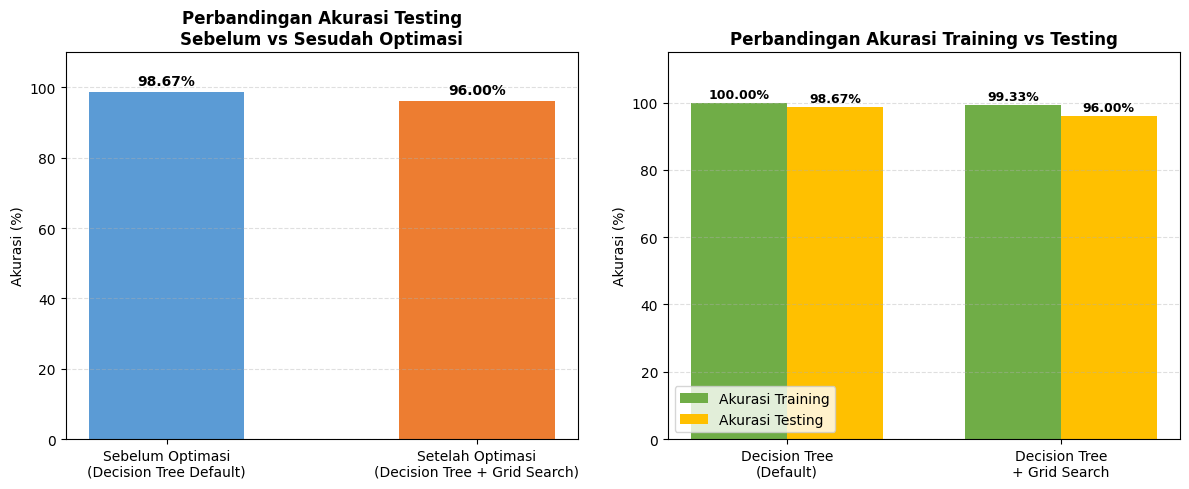

In [34]:

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Grafik 1: Akurasi Testing Sebelum vs Sesudah Optimasi
labels1 = ['Sebelum Optimasi\n(Decision Tree Default)', 'Setelah Optimasi\n(Decision Tree + Grid Search)']
values1 = [akurasi_awal*100, akurasi_grid*100]
colors1 = ['#5B9BD5', '#ED7D31']
bars1 = axes[0].bar(labels1, values1, color=colors1, width=0.5)
axes[0].set_ylim(0, 110)
axes[0].set_ylabel('Akurasi (%)')
axes[0].set_title('Perbandingan Akurasi Testing\nSebelum vs Sesudah Optimasi', fontweight='bold')
for bar, val in zip(bars1, values1):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.2f}%', ha='center', fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Grafik 2: Akurasi Training vs Testing
x = np.arange(2)
width = 0.35
training_vals = [accuracy_score(y_train, dt.predict(X_train))*100, accuracy_score(y_train, best_model.predict(X_train))*100]
testing_vals = [akurasi_awal*100, akurasi_grid*100]
model_labels = ['Decision Tree\n(Default)', 'Decision Tree\n+ Grid Search']

bars_train = axes[1].bar(x - width/2, training_vals, width, label='Akurasi Training', color='#70AD47')
bars_test = axes[1].bar(x + width/2, testing_vals, width, label='Akurasi Testing', color='#FFC000')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_labels)
axes[1].set_ylim(0, 115)
axes[1].set_ylabel('Akurasi (%)')
axes[1].set_title('Perbandingan Akurasi Training vs Testing', fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
for bars in [bars_train, bars_test]:
    for bar in bars:
        h = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2, h + 1.5, f'{h:.2f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

      Metrik  Sebelum Optimasi  Sesudah Optimasi
0   Accuracy          0.986667          0.960000
1  Precision          0.987160          0.961778
2     Recall          0.986667          0.960000
3   F1-Score          0.984570          0.959926


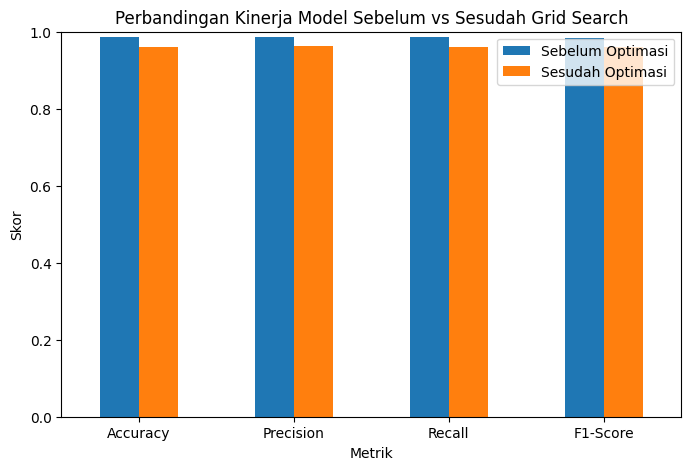

In [35]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Metrik baseline
prec_awal = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec_awal = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_awal = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Metrik optimized
prec_grid = precision_score(y_test, y_pred_grid, average='weighted', zero_division=0)
rec_grid = recall_score(y_test, y_pred_grid, average='weighted', zero_division=0)
f1_grid = f1_score(y_test, y_pred_grid, average='weighted', zero_division=0)

# Tabel perbandingan
import pandas as pd
comparison = pd.DataFrame({
    "Metrik": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Sebelum Optimasi": [akurasi_awal, prec_awal, rec_awal, f1_awal],
    "Sesudah Optimasi": [akurasi_grid, prec_grid, rec_grid, f1_grid]
})
print(comparison)

# Grafik perbandingan
comparison.set_index("Metrik").plot(kind="bar", figsize=(8,5))
plt.title("Perbandingan Kinerja Model Sebelum vs Sesudah Grid Search")
plt.ylabel("Skor")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.show()

In [36]:
from sklearn.metrics import classification_report

print("=== Classification Report - Sebelum Optimasi ===")
print(classification_report(y_test, y_pred, zero_division=0))

print("=== Classification Report - Sesudah Optimasi ===")
print(classification_report(y_test, y_pred_grid, zero_division=0))

=== Classification Report - Sebelum Optimasi ===
              precision    recall  f1-score   support

           4       1.00      0.50      0.67         2
           5       1.00      1.00      1.00         1
           6       0.96      1.00      0.98        26
           7       1.00      1.00      1.00        16
           8       1.00      1.00      1.00        18
           9       1.00      1.00      1.00        12

    accuracy                           0.99        75
   macro avg       0.99      0.92      0.94        75
weighted avg       0.99      0.99      0.98        75

=== Classification Report - Sesudah Optimasi ===
              precision    recall  f1-score   support

           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         1
           6       1.00      0.96      0.98        26
           7       0.93      0.88      0.90        16
           8       0.90      1.00      0.95        18
           9       1.00      1.00 

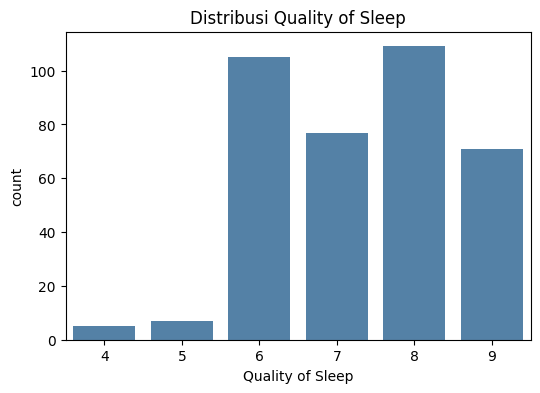

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='Quality of Sleep', data=df, color='steelblue')
plt.title("Distribusi Quality of Sleep")
plt.show()